# Knot-sweep aggregate plots — partial-data friendly

Reads whatever `(N_knots, seed)` runs exist under `knot_sweep_2MHz_100ns/` and re-makes the aggregate plots from them. Mean / std are computed across however many seeds are currently complete for each N_knots — works fine with unequal seed counts. Re-run any time more runs finish.

Outputs (overwritten each run) under `knot_sweep_2MHz_100ns/summary/`:
- `var_obj_vs_knots_partial.png` — mean ± std band, with `n=` annotations for sample size
- `var_obj_per_seed_partial.png` — one labeled line per seed
- `runtime_vs_knots_partial.png` — runtime mean ± std
- `summary_partial.csv` — one row per completed run

In [1]:
using Pkg
Pkg.activate(@__DIR__)

using CairoMakie
using Statistics
using Printf

const SWEEP_DIR = joinpath(@__DIR__, "knot_sweep_2MHz_100ns")
const FIG_DIR   = joinpath(SWEEP_DIR, "summary")
mkpath(FIG_DIR)
println("Looking under: ", SWEEP_DIR)

  Activating 

Looking under: /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/knot_sweep_2MHz_100ns

project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`


In [2]:
# Parse a run_summary.txt of the form  `key = value`  into a Dict.
function parse_run_summary(path)
    d = Dict{String, Any}()
    for line in eachline(path)
        m = match(r"^\s*(\w+)\s*=\s*(.+?)\s*$", line)
        m === nothing && continue
        key, val = String(m.captures[1]), String(m.captures[2])
        if val == "true" || val == "false"
            d[key] = parse(Bool, val)
        else
            parsed = tryparse(Float64, val)
            d[key] = parsed === nothing ? val : parsed
        end
    end
    return d
end

# Walk the sweep directory and collect (N_knots, seed, summary_dict) for every
# run that has a run_summary.txt on disk.
runs = Tuple{Int, Int, Dict{String, Any}}[]
if isdir(SWEEP_DIR)
    for nkdir in sort(filter(d -> startswith(d, "N_knots_"), readdir(SWEEP_DIR)))
        N_knots = parse(Int, replace(nkdir, "N_knots_" => ""))
        nkpath  = joinpath(SWEEP_DIR, nkdir)
        for seeddir in sort(filter(d -> startswith(d, "seed_"), readdir(nkpath)))
            seed = parse(Int, replace(seeddir, "seed_" => ""))
            summary_path = joinpath(nkpath, seeddir, "run_summary.txt")
            if isfile(summary_path)
                push!(runs, (N_knots, seed, parse_run_summary(summary_path)))
            end
        end
    end
end

N_knots_values = sort(unique(r[1] for r in runs))
all_seeds      = sort(unique(r[2] for r in runs))

println("Found $(length(runs)) completed runs:")
for N in N_knots_values
    seeds_for_N = sort([r[2] for r in runs if r[1] == N])
    @printf("  N_knots = %2d : %d seeds %s\n", N, length(seeds_for_N), seeds_for_N)
end
println("All seeds seen: ", all_seeds)

Found 29 completed runs:
  N_knots =  4 : 5 seeds [42, 43, 44, 45, 46]
  N_knots =  8 : 5 seeds [42, 43, 44, 45, 46]
  N_knots = 12 : 5 seeds [42, 43, 44, 45, 46]
  N_knots = 16 : 5 seeds [42, 43, 44, 45, 46]
  N_knots = 20 : 5 seeds [42, 43, 44, 45, 46]
  N_knots = 24 : 4 seeds [42, 43, 44, 45]
All seeds seen: [42, 43, 44, 45, 46]


In [3]:
# For each N_knots, return (mean, std, n) across whichever seeds completed.
# std defaults to 0.0 when only 1 seed is available so error bars don't blow up.
function aggregate_metric(metric_key)
    out = Dict{Int, NamedTuple{(:mean, :std, :n), Tuple{Float64, Float64, Int}}}()
    for N in N_knots_values
        vals = Float64[]
        for r in runs
            r[1] == N || continue
            haskey(r[3], metric_key) || continue
            v = r[3][metric_key]
            v isa Real || continue
            push!(vals, Float64(v))
        end
        if !isempty(vals)
            out[N] = (mean = mean(vals),
                      std  = length(vals) >= 2 ? std(vals) : 0.0,
                      n    = length(vals))
        end
    end
    return out
end

aggregate_metric (generic function with 1 method)

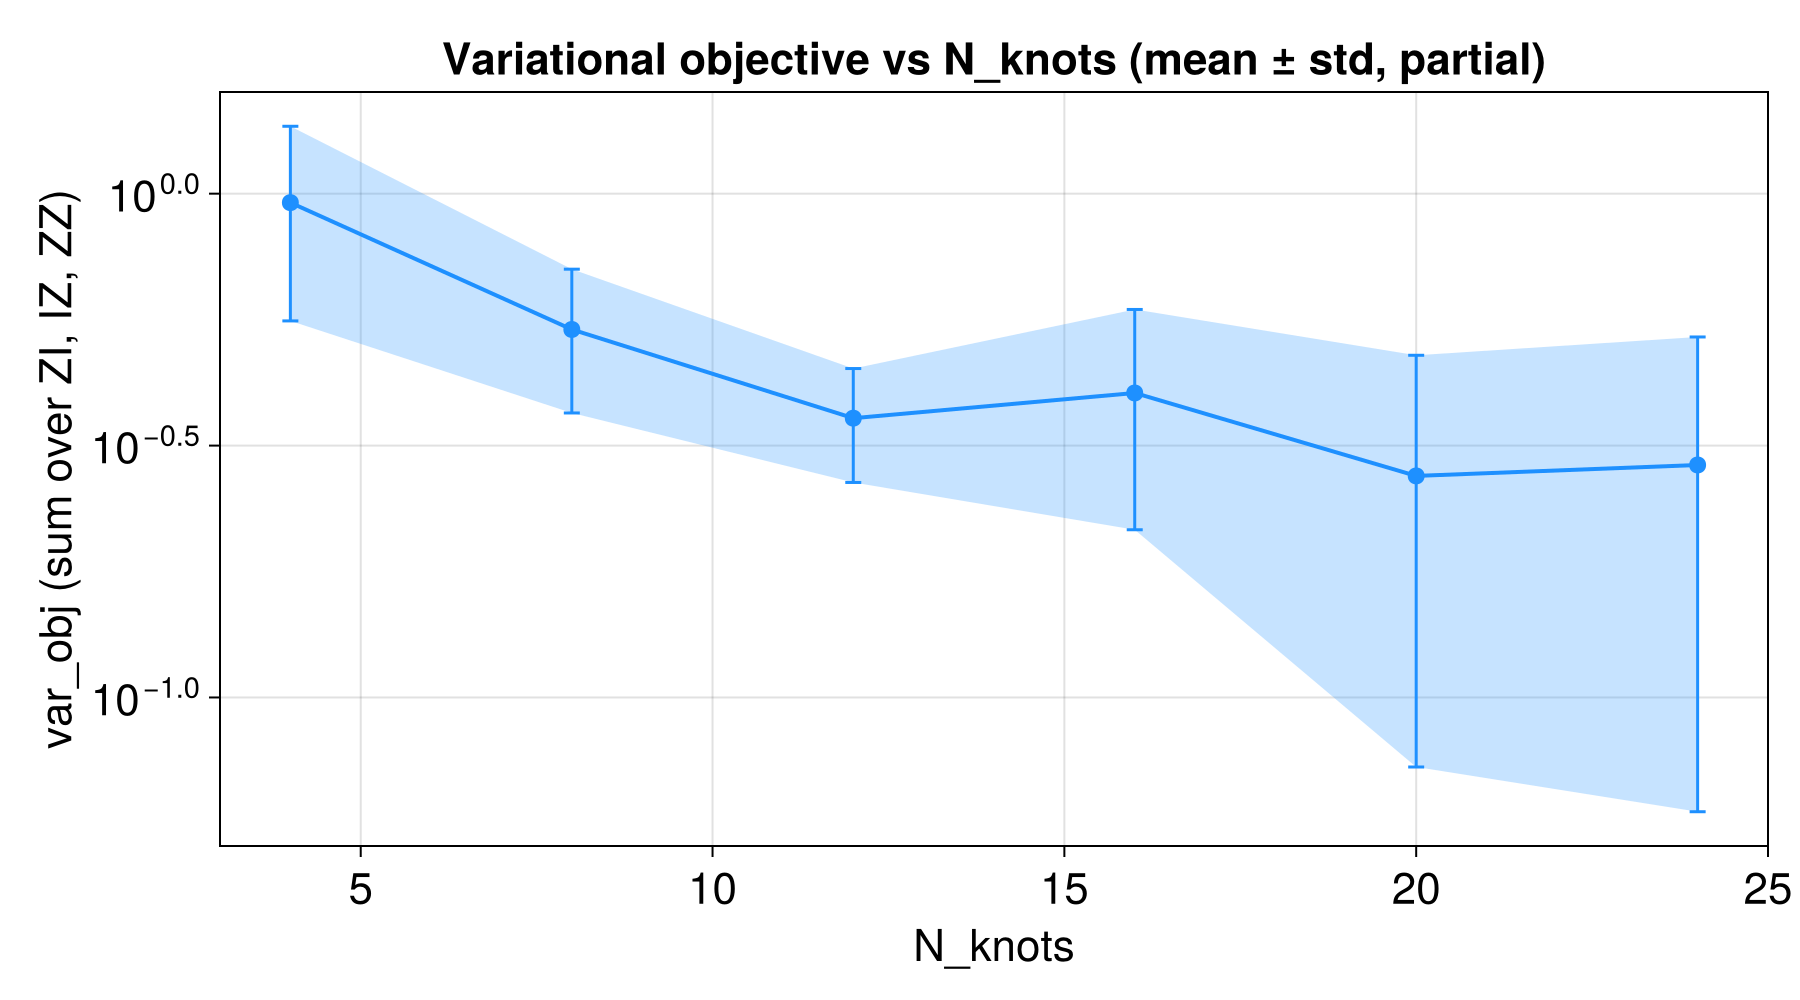

In [4]:
# Aggregate var_obj_sum vs N_knots — mean ± std band + error bars.
let fig = Figure(fontsize = 22, size = (900, 500))
    ax = Axis(fig[1, 1];
        xlabel = "N_knots",
        ylabel = "var_obj (sum over ZI, IZ, ZZ)",
        yscale = log10,
        title  = "Variational objective vs N_knots (mean ± std, partial)")

    agg   = aggregate_metric("var_obj_sum")
    Ns    = sort(collect(keys(agg)))
    means = [agg[N].mean for N in Ns]
    stds  = [agg[N].std  for N in Ns]

    band!(ax, Ns, max.(means .- stds, 1e-16), means .+ stds;
          color = (:dodgerblue, 0.25))
    lines!(ax, Ns, means;    color = :dodgerblue, linewidth = 2)
    scatter!(ax, Ns, means;  color = :dodgerblue, markersize = 12)
    errorbars!(ax, Ns, means, stds; whiskerwidth = 8, color = :dodgerblue)

    save(joinpath(FIG_DIR, "var_obj_vs_knots_partial.png"), fig)
    fig
end

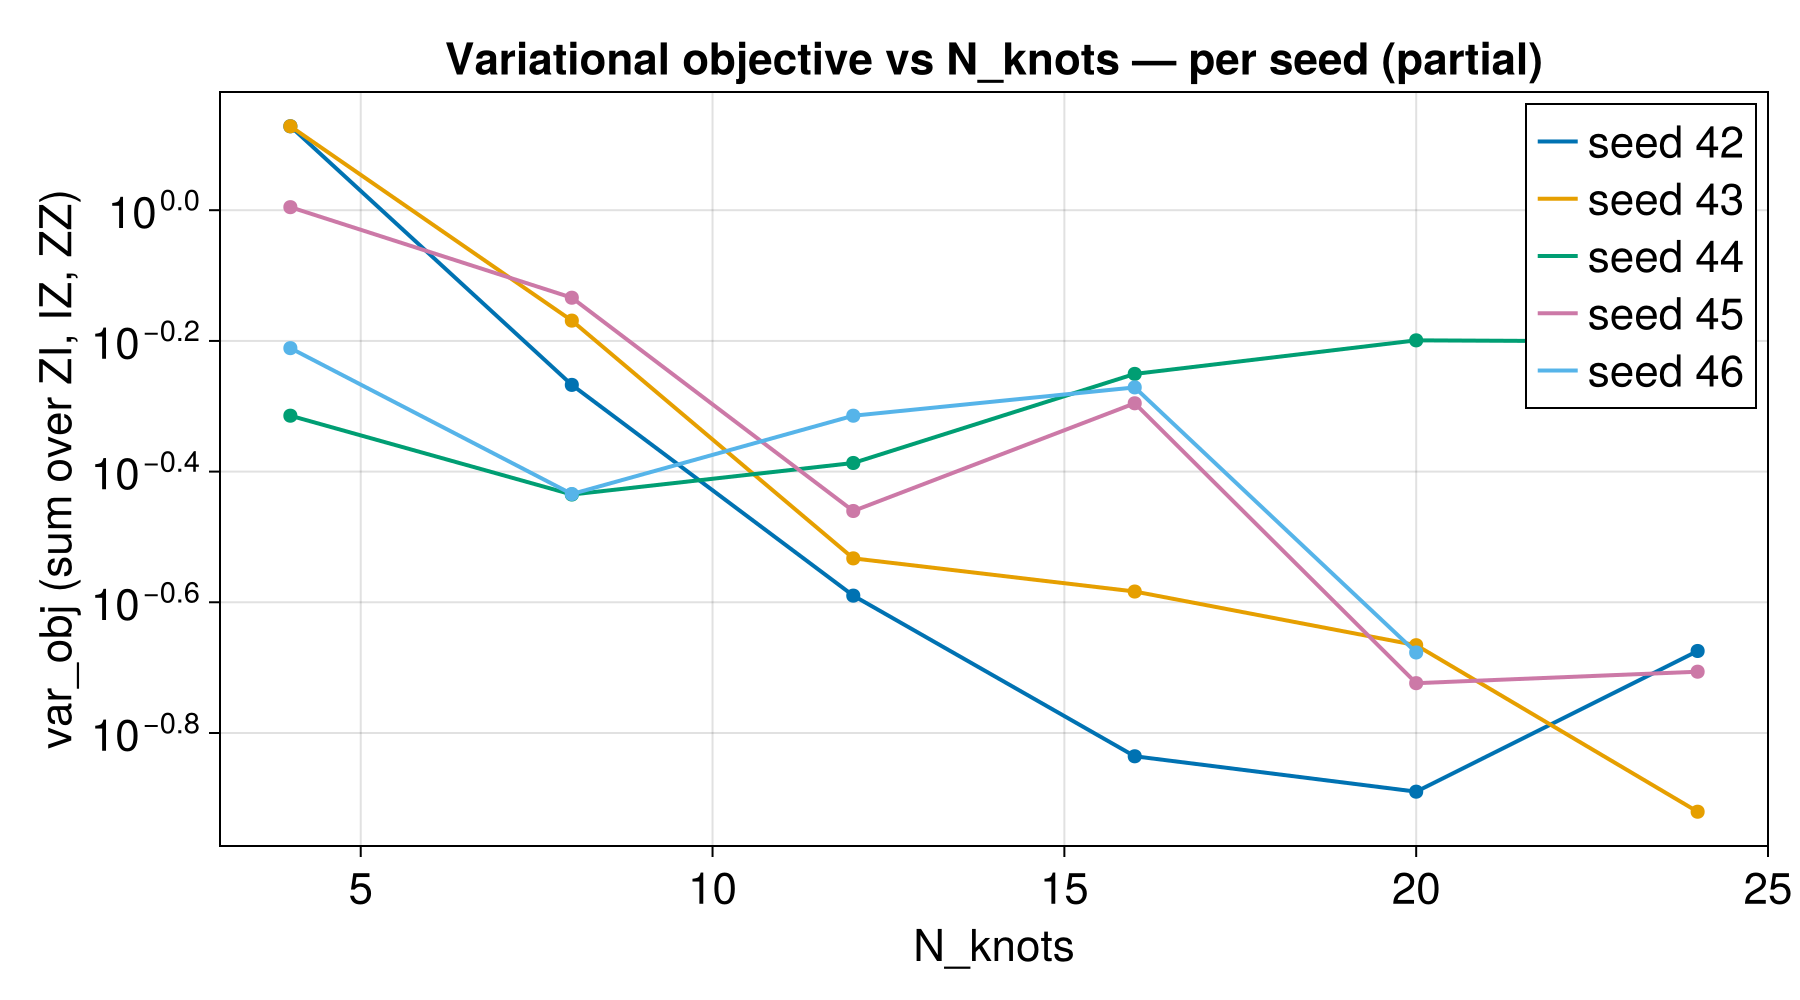

In [5]:
# Per-seed lines — handles seeds that only have a subset of N_knots.
let fig = Figure(fontsize = 22, size = (900, 500))
    ax = Axis(fig[1, 1];
        xlabel = "N_knots",
        ylabel = "var_obj (sum over ZI, IZ, ZZ)",
        yscale = log10,
        title  = "Variational objective vs N_knots — per seed (partial)")

    seed_colors = Makie.wong_colors()
    for (i, seed) in enumerate(all_seeds)
        pairs = sort([(r[1], r[3]["var_obj_sum"]) for r in runs
                       if r[2] == seed && haskey(r[3], "var_obj_sum")
                       && r[3]["var_obj_sum"] isa Real])
        isempty(pairs) && continue
        xs = [p[1] for p in pairs]
        ys = [p[2] for p in pairs]
        col = seed_colors[mod1(i, length(seed_colors))]
        lines!(ax, xs, ys;   color = col, linewidth = 2, label = "seed $seed")
        scatter!(ax, xs, ys; color = col, markersize = 10)
    end
    axislegend(ax; position = :rt)
    save(joinpath(FIG_DIR, "var_obj_per_seed_partial.png"), fig)
    fig
end

In [6]:
# Per-error breakdown — ZI / IZ / ZZ separately, mean ± std.
let fig = Figure(fontsize = 22, size = (900, 500))
    ax = Axis(fig[1, 1];
        xlabel = "N_knots",
        ylabel = "var_obj (per error)",
        yscale = log10,
        title  = "Per-error variational objective (partial)")

    err_specs = [(:crimson, "ZI", "var_obj_ZI"),
                 (:forestgreen, "IZ", "var_obj_IZ"),
                 (:purple, "ZZ", "var_obj_ZZ")]
    for (col, name, key) in err_specs
        agg = aggregate_metric(key)
        Ns    = sort(collect(keys(agg)))
        isempty(Ns) && continue
        means = [agg[N].mean for N in Ns]
        stds  = [agg[N].std  for N in Ns]
        band!(ax, Ns, max.(means .- stds, 1e-16), means .+ stds; color = (col, 0.2))
        lines!(ax, Ns, means;    color = col, linewidth = 2, label = name)
        scatter!(ax, Ns, means;  color = col, markersize = 10)
        errorbars!(ax, Ns, means, stds; whiskerwidth = 6, color = col)
    end
    axislegend(ax; position = :rt)
    save(joinpath(FIG_DIR, "var_obj_per_error_partial.png"), fig)
    fig
end

DomainError: DomainError with -0.030500968603465684:
log10 was called with a negative real argument but will only return a complex result if called with a complex argument. Try log10(Complex(x)).

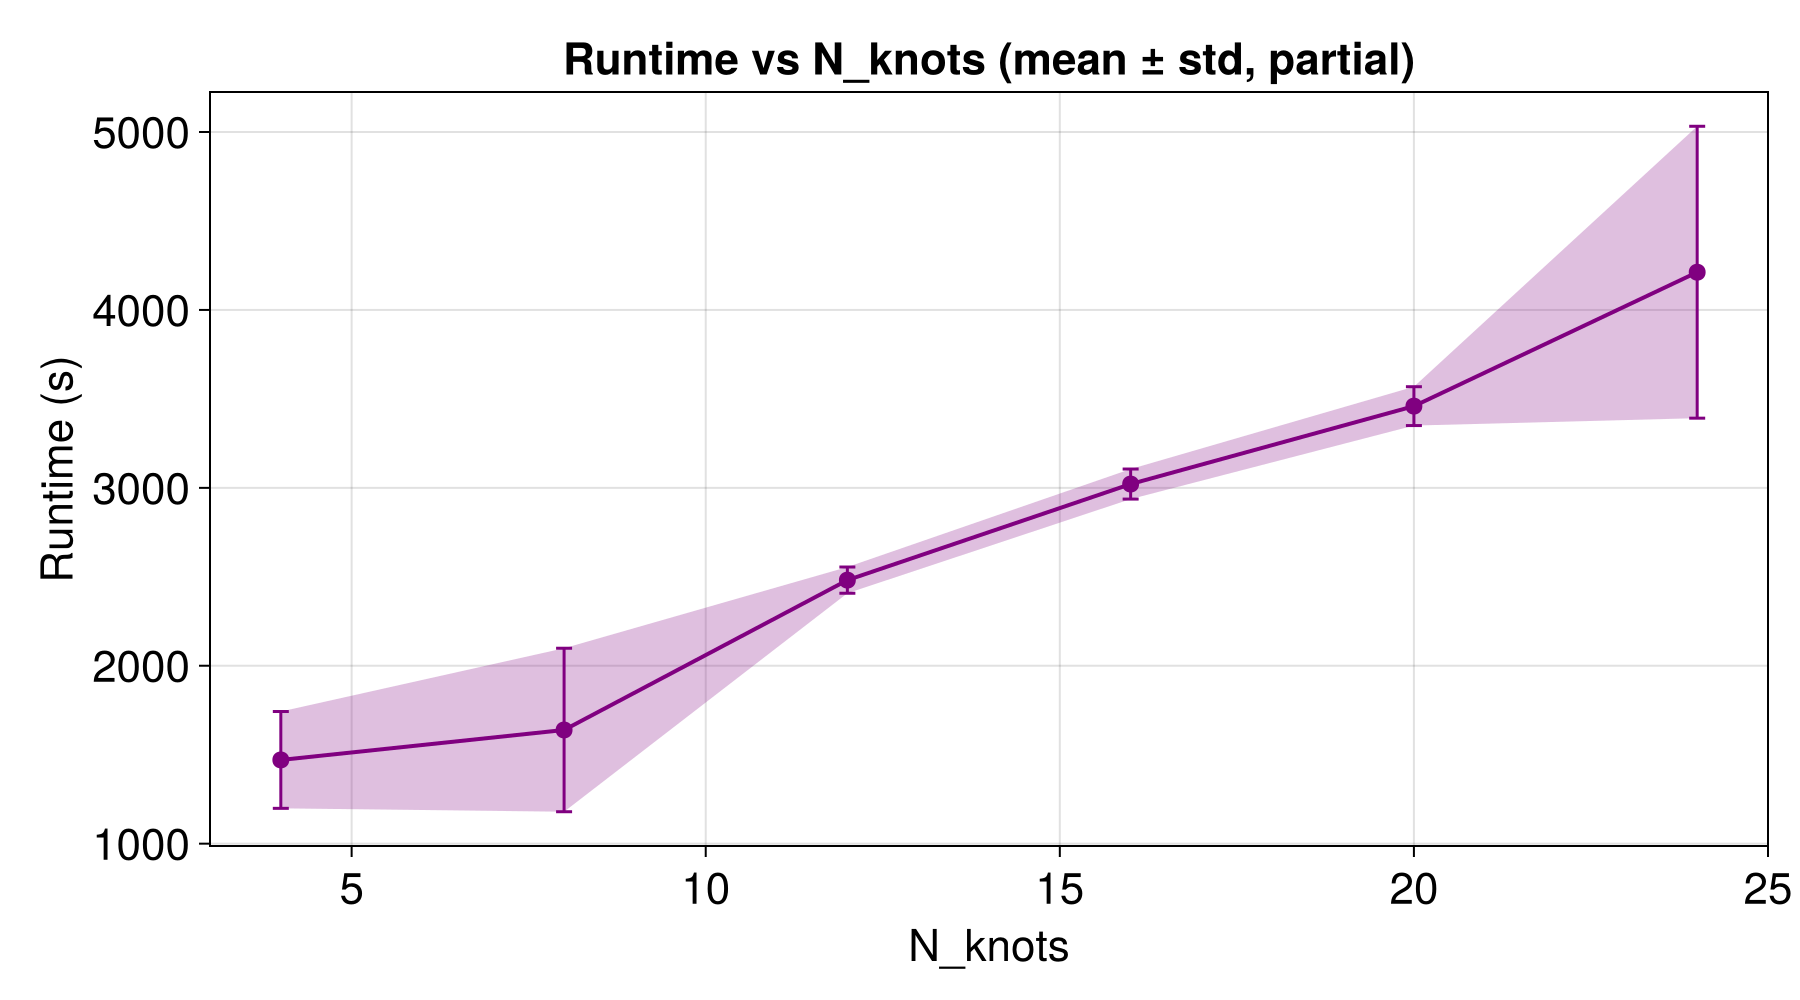

In [7]:
# Runtime vs N_knots — mean ± std (linear y).
let fig = Figure(fontsize = 22, size = (900, 500))
    ax = Axis(fig[1, 1];
        xlabel = "N_knots",
        ylabel = "Runtime (s)",
        title  = "Runtime vs N_knots (mean ± std, partial)")

    agg   = aggregate_metric("runtime_s")
    Ns    = sort(collect(keys(agg)))
    means = [agg[N].mean for N in Ns]
    stds  = [agg[N].std  for N in Ns]

    band!(ax, Ns, means .- stds, means .+ stds; color = (:purple, 0.25))
    lines!(ax, Ns, means;    color = :purple, linewidth = 2)
    scatter!(ax, Ns, means;  color = :purple, markersize = 12)
    errorbars!(ax, Ns, means, stds; whiskerwidth = 8, color = :purple)

    save(joinpath(FIG_DIR, "runtime_vs_knots_partial.png"), fig)
    fig
end

In [8]:
# Write a partial summary.csv with one row per completed run.
csv_path = joinpath(FIG_DIR, "summary_partial.csv")
open(csv_path, "w") do io
    println(io, "N_knots,seed,runtime_s,F_flat,F_full,var_obj_ZI,var_obj_IZ,var_obj_ZZ,var_obj_sum,converged")
    for (N, seed, d) in sort(runs; by = r -> (r[1], r[2]))
        @printf(io, "%d,%d,%.4f,%.10g,%.10g,%.10g,%.10g,%.10g,%.10g,%s\n",
            N, seed,
            get(d, "runtime_s", NaN),
            get(d, "F_flat", NaN),
            get(d, "F_full", NaN),
            get(d, "var_obj_ZI", NaN),
            get(d, "var_obj_IZ", NaN),
            get(d, "var_obj_ZZ", NaN),
            get(d, "var_obj_sum", NaN),
            get(d, "converged", "?"))
    end
end
println("Wrote: ", csv_path)

Wrote: /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/knot_sweep_2MHz_100ns/summary/summary_partial.csv
